# Quantifying Momentum in Football: A Match-Level xG Analysis

The premise of this project is to model how a football game is constantly evolving and how momentum swings minute by minute using event data.

Initially we will analyse one game and go from there.

The below is so I can find the match id's within the Statsbomb open data

In [39]:
import subprocess
import threading

def run_streamlit():
    subprocess.run(["streamlit", "run", r"C:\Users\tamee\Downloads\statsbomb_browser.py"])

thread = threading.Thread(target=run_streamlit, daemon=True)
thread.start()


Argentina 3 - 3 France


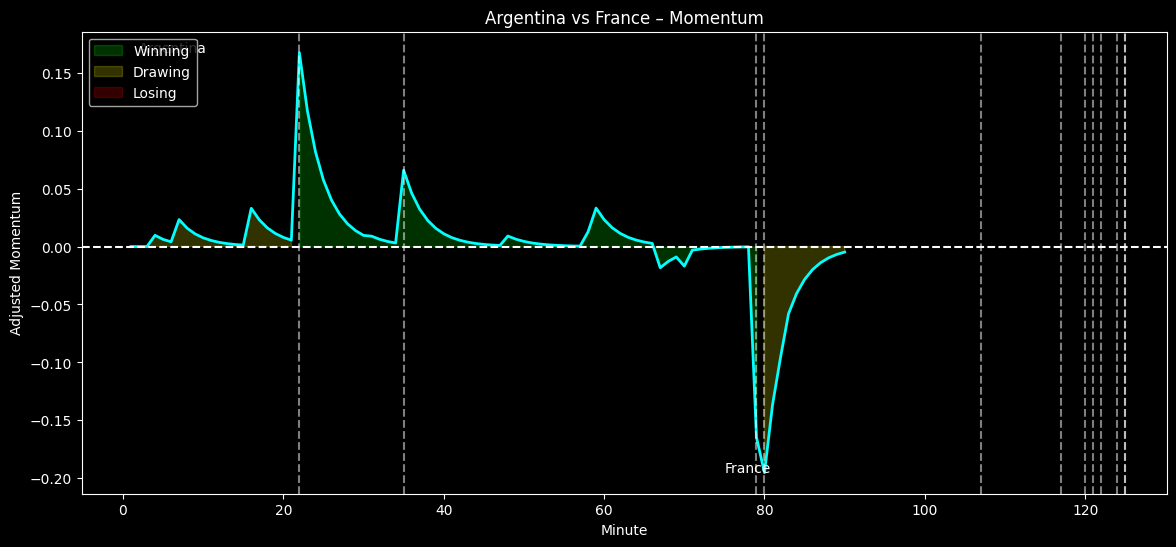

Average Momentum (Winning): 0.011902311747626345
Average Momentum (Drawing): -0.013139508900056288
Average Momentum (Losing): nan

Costa Rica 2 - 4 Germany


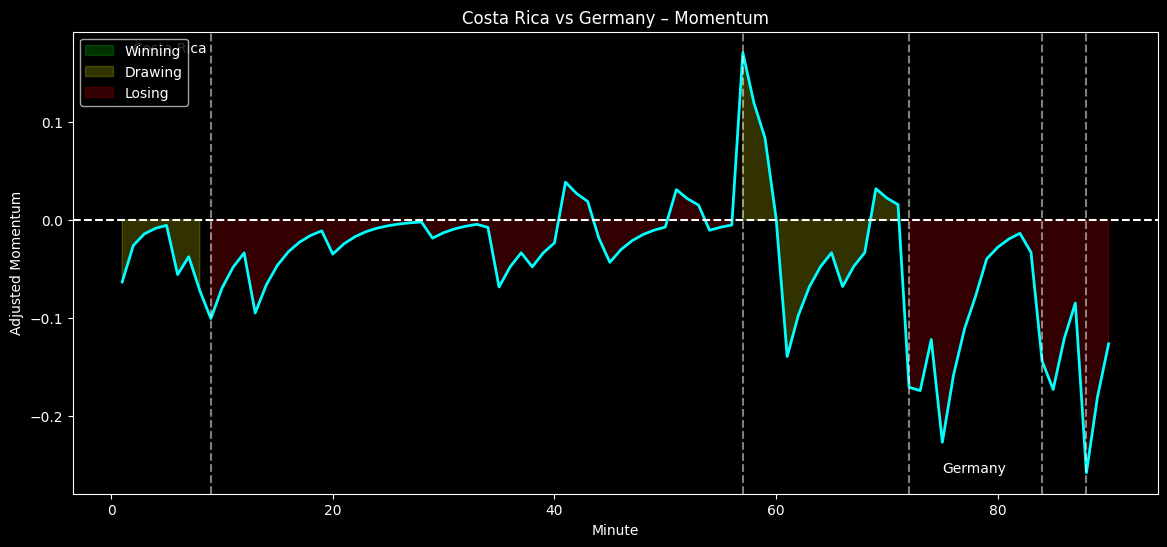

Average Momentum (Winning): nan
Average Momentum (Drawing): -0.01622096208812471
Average Momentum (Losing): -0.048518143959072314

England 1 - 2 France


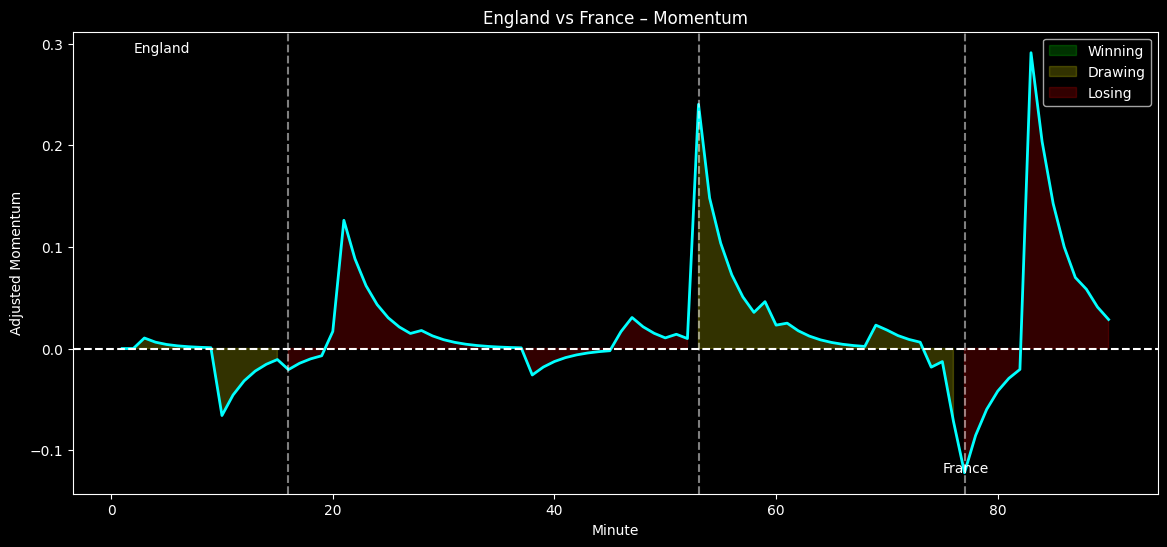

Average Momentum (Winning): nan
Average Momentum (Drawing): 0.015404898447419435
Average Momentum (Losing): 0.01999929647310533


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsbombpy import sb
import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.simplefilter("ignore", NoAuthWarning)

competition_id = 43
season_id = 106

matches = sb.matches(competition_id=competition_id, season_id=season_id)

match_ids = [3869685, 3857292, 3869354]

for match_id in match_ids:
    match_df = matches[matches["match_id"] == match_id]
    
    if match_df.empty:
        print(f"Match ID {match_id} not found. Skipping...")
        continue

    match = match_df.iloc[0]
    home_team = match["home_team"]
    away_team = match["away_team"]
    home_score = match["home_score"]
    away_score = match["away_score"]

    print(f"\n{home_team} {home_score} - {away_score} {away_team}")

    events = sb.events(match_id=match_id)
    shots = events[events["type"] == "Shot"].copy()
    shots["xG"] = shots["shot_statsbomb_xg"].fillna(0)
    shots["goal"] = shots["shot_outcome"] == "Goal"

    minutes = pd.DataFrame({"minute": range(1, 91)})
    home_xg = shots[shots["team"] == home_team].groupby("minute")["xG"].sum()
    away_xg = shots[shots["team"] == away_team].groupby("minute")["xG"].sum()

    timeline = minutes.merge(home_xg, on="minute", how="left").rename(columns={"xG": "home_xg"})
    timeline = timeline.merge(away_xg, on="minute", how="left").rename(columns={"xG": "away_xg"})
    timeline = timeline.fillna(0)

    timeline["xg_diff"] = timeline["home_xg"] - timeline["away_xg"]
    timeline["momentum"] = timeline["xg_diff"].ewm(alpha=0.3).mean()

    home_goals = 0
    away_goals = 0
    game_states = []

    for minute in timeline["minute"]:
        goals_this_min = shots[(shots["minute"] == minute) & (shots["goal"])]
        for _, row in goals_this_min.iterrows():
            if row["team"] == home_team:
                home_goals += 1
            else:
                away_goals += 1

        if home_goals > away_goals:
            game_states.append(1)
        elif home_goals < away_goals:
            game_states.append(-1)
        else:
            game_states.append(0)

    timeline["game_state"] = game_states

    def adjust_momentum(row):
        if row["game_state"] == -1:
            return row["momentum"] * 1.3
        elif row["game_state"] == 1:
            return row["momentum"] * 0.7
        else:
            return row["momentum"]

    timeline["adjusted_momentum"] = timeline.apply(adjust_momentum, axis=1)

    plt.style.use("dark_background")
    plt.figure(figsize=(14,6))
    plt.plot(timeline["minute"], timeline["adjusted_momentum"], linewidth=2, color="cyan")

    plt.fill_between(timeline["minute"], timeline["adjusted_momentum"],
                     where=timeline["game_state"] == 1,
                     alpha=0.2,
                     color="lime",
                     label="Winning"
                     )
    
    plt.fill_between(timeline["minute"], timeline["adjusted_momentum"],
                     where=timeline["game_state"] == 0,
                     alpha=0.2,
                     color="yellow", 
                     label="Drawing"
                    )
    
    plt.fill_between(timeline["minute"], timeline["adjusted_momentum"],
                     where=timeline["game_state"] == -1,
                     alpha=0.2,
                     color="red",
                     label="Losing"
                     )

    plt.text(2, timeline["adjusted_momentum"].max(), home_team, fontsize=10)
    plt.text(75, timeline["adjusted_momentum"].min(), away_team, fontsize=10)

    goals = shots[shots["goal"]]
    for _, row in goals.iterrows():
        plt.axvline(x=row["minute"], linestyle="--", alpha=0.5)

    plt.axhline(0, linestyle="--")
    plt.title(f"{home_team} vs {away_team} – Momentum")
    plt.xlabel("Minute")
    plt.ylabel("Adjusted Momentum")
    plt.legend()
    plt.show()

    winning = timeline[timeline["game_state"] == 1]
    drawing = timeline[timeline["game_state"] == 0]
    losing = timeline[timeline["game_state"] == -1]

    print("Average Momentum (Winning):", winning["adjusted_momentum"].mean())
    print("Average Momentum (Drawing):", drawing["adjusted_momentum"].mean())
    print("Average Momentum (Losing):", losing["adjusted_momentum"].mean())